In [42]:
import numpy as np
import sympy as sp
from matplotlib import pyplot as plt

Potrzebuję metodę bisekcji:
Dane wejściowe: funkcja, argument1, argument2, błąd docelowy
Dane wyjściowe: pierwiastek

In [3]:
λ = -(1/10) + 1j # stała λ

# funkcja metody bisekcji
def bisect(f, arg1, arg2, e):
    while np.abs(arg1 - arg2) > e:
        if f(arg1) * f((arg1 + arg2)/2) < 0:
            arg2 = (arg1 + arg2)/2
        else:
            arg1 = (arg1 + arg2)/2
    return (arg1 + arg2)/2

R = lambda h: np.abs(1 + (λ * h) + ((λ * h)**2)/2) - 1

h_gran = bisect(R, 1/2, 2, 10**(-12))
print(h_gran)

1.0424613808173717


Warto mieć w pamięci wzory definiujące metody Rungego-Kutny:
$$
x_{k+1} = x_k + h\sum_{i=1}^{s}{b_i K_i},\quad K_i = f\bigg( t_k + c_i h,\space x_k + h\sum_{j=1}^{s}{a_{ij} K_j}\bigg),\quad i = 1, 2,\dots , s.
$$

Schemat Heunego, użyty w tym zadaniu, ma postać:
$$
A' = \begin{bmatrix}
0 & 0 \\
1/2 & 0
\end{bmatrix},\space
b^T = \begin{bmatrix}
\frac{1}{2} & \frac{1}{2}
\end{bmatrix},\space
c = \begin{bmatrix}
0 \\
\frac{1}{2}
\end{bmatrix}.
$$

Schemat ten pociąga wzór:
$$ x_{k+1} = x_k + \frac{h}{2} f(t_k ,\space x_k) + \frac{h}{2} f\Big( t_k + \frac{h}{2},\space x_k + hf(t_k ,x_k )\Big) $$

W naszym przypadku funkcja f to macierz 
$$
A = \begin{bmatrix}
-\frac{1}{10} & 1 \\
-1 & -\frac{1}{10}
\end{bmatrix},
$$
natomiast wartość początkowa to
$$
x(0)=\begin{bmatrix}
\frac{1}{2} \\
-\frac{1}{3}
\end{bmatrix}
$$

In [45]:
h = h_gran

Ap = sp.Matrix([[0, 0],
               [1/2, 0]])
x0 = sp.Matrix([1/2, -1/3])
b = sp.Matrix([1/2, 1/2])
c = sp.Matrix([0, 1/2])

A = sp.Matrix([[-1/10, 1], [-1, -1/10]])

f = lambda x: A*x

# f(x0)
K1 = lambda x: f(x)

K2 = lambda x: f(x + h*(1/2)*K1(x))

nast = lambda xk: xk + h*(b[0]*K1(xk) + b[1]*K2(xk))

def rozwiazanie(skalar, i):
    xk = x0
    rozw1 = []
    rozw2 = []
    rozw1.append(x0[0])
    rozw2.append(x0[1])
    for k in range(i):
        xk1 = nast(xk)
        rozw1.append(xk1[0])
        rozw2.append(xk1[1])
        xk = xk1
    return rozw1, rozw2

print(rozwiazanie(0.9, 50))


# print(x0[0])


([0.500000000000000, -0.0159804096205695, -0.704660676662250, -0.861466193986130, -0.115054658456520, 1.03533767393767, 1.45541631165308, 0.406836299801888, -1.48283622267966, -2.41591461624252, -0.998156257455088, 2.05673827079082, 3.94501425257376, 2.12918386778720, -2.73263517725545, -6.34097036809511, -4.20722704448313, 3.40832214140982, 10.0333700109102, 7.91075140167671, -3.82150389009082, -15.6223985536525, -14.3512857763628, 3.40059918260976, 23.9135015317049, 25.3211603835725, -1.00164251744956, -35.9267872276556, -43.6655425995870, -5.54521737727016, 52.8379391477276, 73.8293257573674, 20.2021915163432, -75.7662114802042, -122.640863867521, -49.9966121250345, 105.252056136397, 200.399872336967, 107.099963862649, -140.140508475105, -322.324390224081, -212.170695326877, 175.371972402554, 510.358520534716, 399.645344063574, -197.824639057485, -795.205480170444, -725.979917231212, 178.767035059350, 1218.15083635504, 1282.26985484032], [-0.333333333333333, -0.702992295019823, -0.4

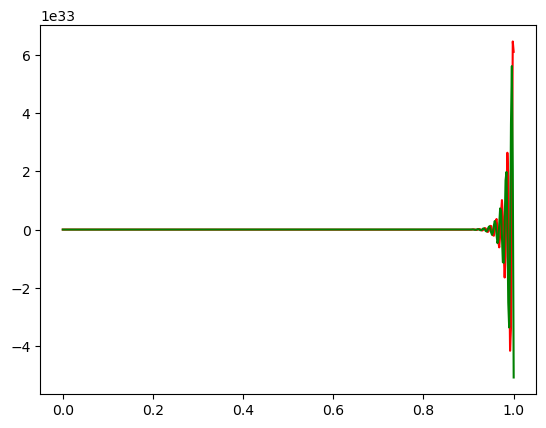

In [48]:
fig, ax = plt.subplots()
ax.plot(np.linspace(0, 1, 501), rozwiazanie(0.1, 500)[0], color = 'r')
ax.plot(np.linspace(0, 1, 501), rozwiazanie(0.1, 500)[1], color = 'g')
plt.show()